# Módulo 2 — Course Recommender: Análisis Exploratorio (EDA)

En este notebook exploramos los dos datasets del recomendador:
- **platzi_courses.csv** — catálogo de 80 cursos con sus atributos
- **platzi_interactions.csv** — 5,000 estudiantes × cursos tomados (matriz dispersa)

El objetivo es entender los patrones de consumo antes de construir el modelo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
os.makedirs('../reports', exist_ok=True)

print('Librerías cargadas OK')

Librerías cargadas OK


## 1. Carga de Datos

In [2]:
df_courses = pd.read_csv('../data/raw/platzi_courses.csv')
df_int     = pd.read_csv('../data/raw/platzi_interactions.csv')

print('=== CURSOS ===')
print(f'Shape: {df_courses.shape}')
display(df_courses.head(3))

print('\n=== INTERACCIONES ===')
print(f'Shape: {df_int.shape}')
display(df_int.head(3))

=== CURSOS ===
Shape: (83, 8)


,course_id,name,school,difficulty,duration_h,popularity,avg_rating,total_students
0,CRS-001,Fundamentos de Python,Programacion,Basico,6,0.90,4.4,7035
1,CRS-002,Python Intermedio,Programacion,Intermedio,8,0.85,4.1,6612
2,CRS-003,Python para Automatizacion,Programacion,Intermedio,10,0.70,4.2,5559



=== INTERACCIONES ===
Shape: (44864, 7)


,student_id,course_id,progress,rating,completed,date_started,date_last_access
0,PLZ-00001,CRS-021,19,NaN,0,2024-12-17,2026-04-24
1,PLZ-00001,CRS-046,58,NaN,0,2025-05-17,2026-04-17
2,PLZ-00001,CRS-037,76,2.6,0,2025-01-02,2026-04-23


In [3]:
print('--- Tipos de datos: Cursos ---')
print(df_courses.dtypes)
print('\nNullos:', df_courses.isnull().sum().sum())

print('\n--- Tipos de datos: Interacciones ---')
print(df_int.dtypes)
print('\nNullos por columna:')
print(df_int.isnull().sum())

--- Tipos de datos: Cursos ---
course_id             str
name                  str
school                str
difficulty            str
duration_h          int64
popularity        float64
avg_rating        float64
total_students      int64
dtype: object

Nullos: 0

--- Tipos de datos: Interacciones ---
student_id              str
course_id               str
progress              int64
rating              float64
completed             int64
date_started            str
date_last_access        str
dtype: object

Nullos por columna:
student_id              0
course_id               0
progress                0
rating              24985
completed               0
date_started            0
date_last_access        0
dtype: int64


## 2. Catálogo de Cursos

Analizamos la distribución de cursos por escuela, dificultad y duración.

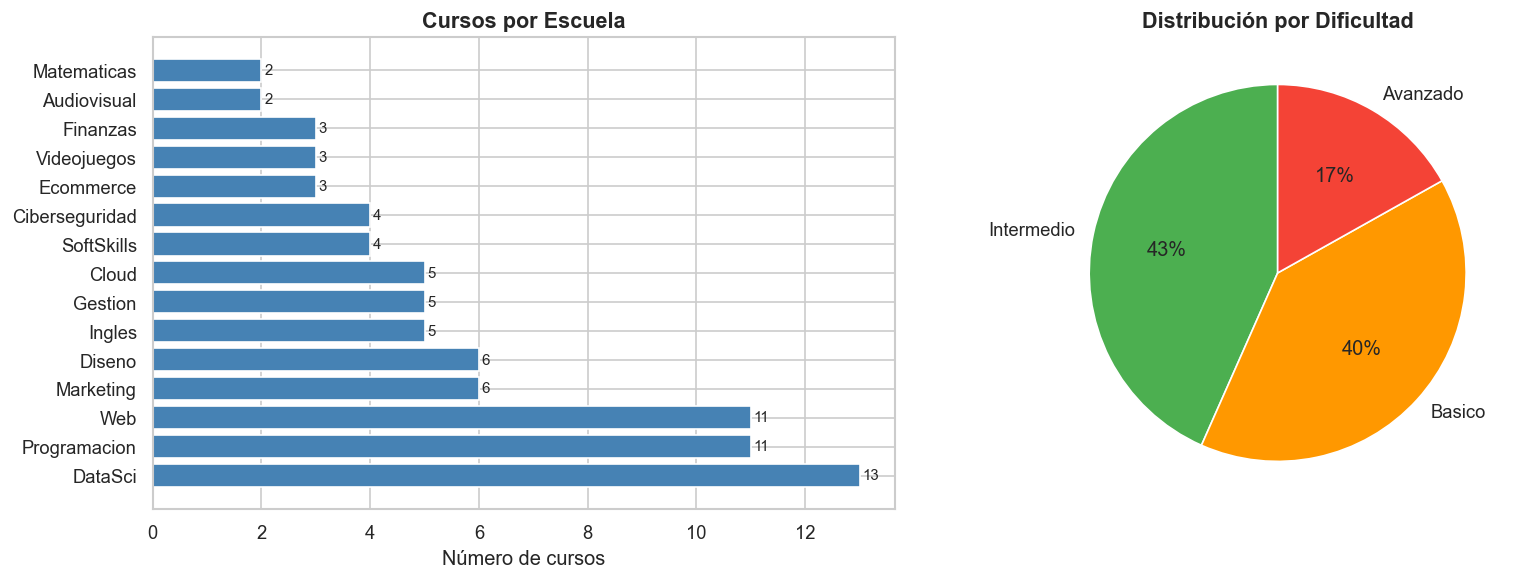

Gráfico guardado en reports/


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cursos por escuela
school_counts = df_courses['school'].value_counts()
axes[0].barh(school_counts.index, school_counts.values, color='steelblue')
axes[0].set_title('Cursos por Escuela', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Número de cursos')
for i, v in enumerate(school_counts.values):
    axes[0].text(v + 0.05, i, str(v), va='center', fontsize=9)

# Cursos por dificultad
diff_counts = df_courses['difficulty'].value_counts()
colors = ['#4CAF50', '#FF9800', '#F44336']
axes[1].pie(diff_counts.values, labels=diff_counts.index, autopct='%1.0f%%',
            colors=colors, startangle=90)
axes[1].set_title('Distribución por Dificultad', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/recommender_01_catalogo.png', bbox_inches='tight')
plt.show()
print('Gráfico guardado en reports/')

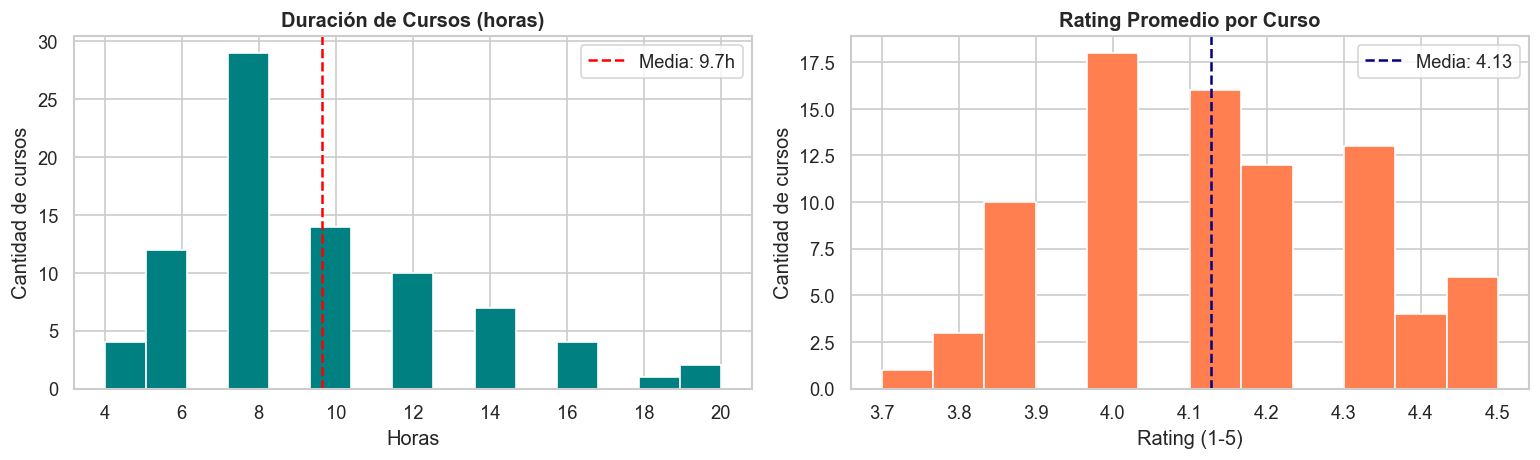

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribución de duración
axes[0].hist(df_courses['duration_h'], bins=15, color='teal', edgecolor='white')
axes[0].set_title('Duración de Cursos (horas)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Horas')
axes[0].set_ylabel('Cantidad de cursos')
axes[0].axvline(df_courses['duration_h'].mean(), color='red', linestyle='--',
                label=f'Media: {df_courses["duration_h"].mean():.1f}h')
axes[0].legend()

# Distribución de rating promedio
axes[1].hist(df_courses['avg_rating'], bins=12, color='coral', edgecolor='white')
axes[1].set_title('Rating Promedio por Curso', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Rating (1-5)')
axes[1].set_ylabel('Cantidad de cursos')
axes[1].axvline(df_courses['avg_rating'].mean(), color='navy', linestyle='--',
                label=f'Media: {df_courses["avg_rating"].mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/recommender_02_duracion_rating.png', bbox_inches='tight')
plt.show()

In [6]:
print('=== Estadísticas del catálogo ===')
print(df_courses[['duration_h', 'avg_rating', 'total_students', 'popularity']].describe().round(2))

=== Estadísticas del catálogo ===
       duration_h  avg_rating  total_students  popularity
count       83.00       83.00           83.00       83.00
mean         9.65        4.13         3500.71        0.70
std          3.48        0.19         2249.56        0.11
min          4.00        3.70          402.00        0.40
25%          8.00        4.00         1439.50        0.62
50%          8.00        4.10         2986.00        0.68
75%         12.00        4.30         5567.50        0.78
max         20.00        4.50         8130.00        0.92


## 3. Análisis de Interacciones

Estudiamos cómo los estudiantes consumen cursos: cuántos toman, cuáles son los más populares, etc.

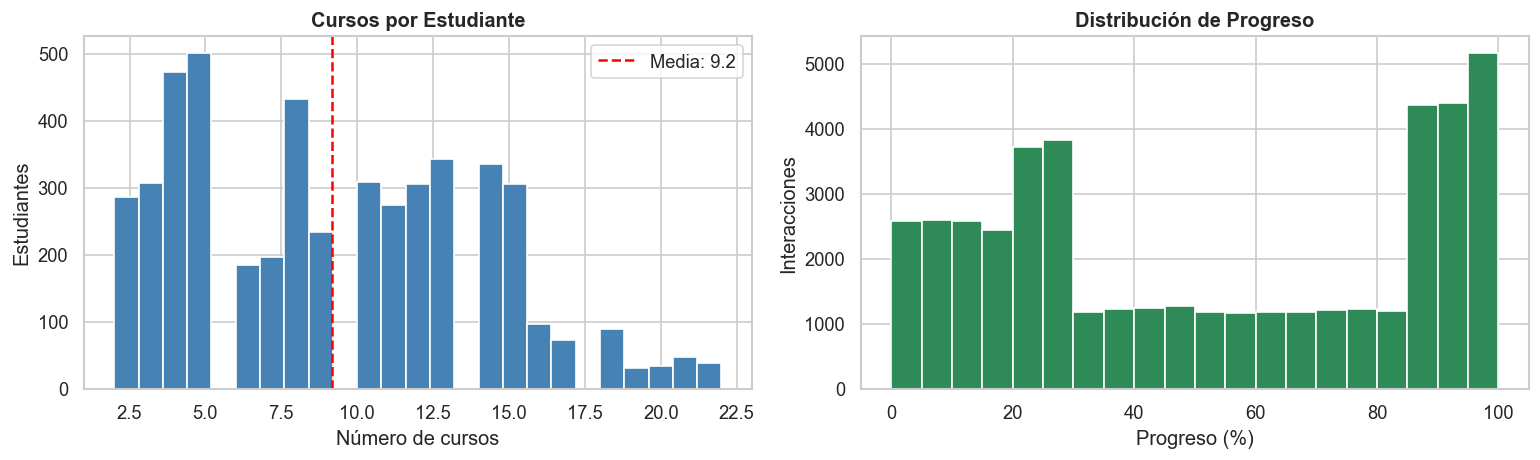

Estudiantes totales:        4,891
Interacciones totales:      44,864
Media cursos/estudiante:    9.2
Mediana cursos/estudiante:  9
Porcentaje completados:     21.3%


In [7]:
courses_per_student = df_int.groupby('student_id').size()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(courses_per_student, bins=25, color='steelblue', edgecolor='white')
axes[0].set_title('Cursos por Estudiante', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Número de cursos')
axes[0].set_ylabel('Estudiantes')
axes[0].axvline(courses_per_student.mean(), color='red', linestyle='--',
                label=f'Media: {courses_per_student.mean():.1f}')
axes[0].legend()

# Distribución de progreso
axes[1].hist(df_int['progress'], bins=20, color='seagreen', edgecolor='white')
axes[1].set_title('Distribución de Progreso', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Progreso (%)')
axes[1].set_ylabel('Interacciones')

plt.tight_layout()
plt.savefig('../reports/recommender_03_interacciones.png', bbox_inches='tight')
plt.show()

print(f'Estudiantes totales:        {courses_per_student.shape[0]:,}')
print(f'Interacciones totales:      {len(df_int):,}')
print(f'Media cursos/estudiante:    {courses_per_student.mean():.1f}')
print(f'Mediana cursos/estudiante:  {courses_per_student.median():.0f}')
print(f'Porcentaje completados:     {df_int["completed"].mean():.1%}')

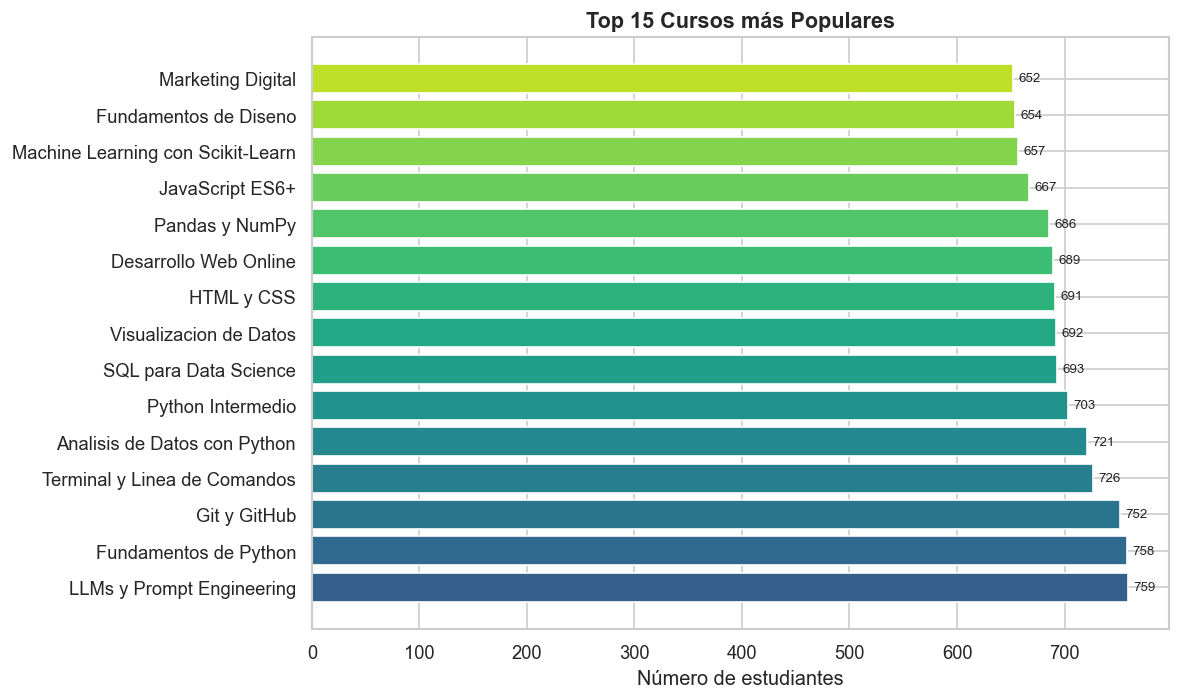

In [8]:
# Top 15 cursos más populares
top_courses = (df_int.groupby('course_id')
               .size()
               .reset_index(name='interacciones')
               .merge(df_courses[['course_id', 'name', 'school']], on='course_id')
               .sort_values('interacciones', ascending=False)
               .head(15))

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_courses)))
bars = ax.barh(top_courses['name'], top_courses['interacciones'], color=colors)
ax.set_title('Top 15 Cursos más Populares', fontsize=13, fontweight='bold')
ax.set_xlabel('Número de estudiantes')
for bar, val in zip(bars, top_courses['interacciones']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=8)
plt.tight_layout()
plt.savefig('../reports/recommender_04_top_cursos.png', bbox_inches='tight')
plt.show()

## 4. Distribución de Ratings

In [9]:
ratings = df_int['rating'].dropna()
print(f'Interacciones con rating: {len(ratings):,} ({len(ratings)/len(df_int):.1%})')
print(f'Rating promedio: {ratings.mean():.2f}')
print(f'Distribución:')
print(pd.cut(ratings, bins=[0.9,1.9,2.9,3.9,4.9,5.1],
             labels=['1','2','3','4','5']).value_counts().sort_index())

Interacciones con rating: 19,879 (44.3%)
Rating promedio: 3.15
Distribución:
rating
1     774
2    7543
3    8662
4    2693
5     207
Name: count, dtype: int64


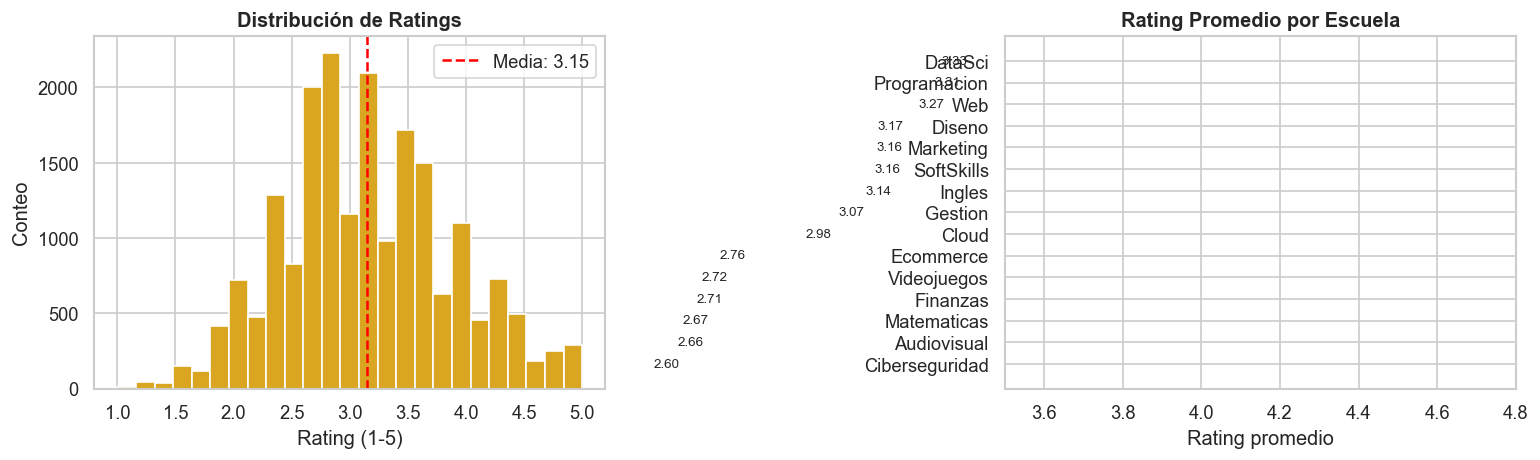

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma de ratings
axes[0].hist(ratings, bins=25, color='goldenrod', edgecolor='white')
axes[0].set_title('Distribución de Ratings', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Rating (1-5)')
axes[0].set_ylabel('Conteo')
axes[0].axvline(ratings.mean(), color='red', linestyle='--',
                label=f'Media: {ratings.mean():.2f}')
axes[0].legend()

# Rating promedio por escuela
rating_by_school = (df_int.dropna(subset=['rating'])
                    .merge(df_courses[['course_id', 'school']], on='course_id')
                    .groupby('school')['rating']
                    .mean()
                    .sort_values())
axes[1].barh(rating_by_school.index, rating_by_school.values, color='coral')
axes[1].set_title('Rating Promedio por Escuela', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Rating promedio')
axes[1].set_xlim(3.5, 4.8)
for i, v in enumerate(rating_by_school.values):
    axes[1].text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../reports/recommender_05_ratings.png', bbox_inches='tight')
plt.show()

## 5. Análisis de Sparsidad

La **sparsidad** es la fracción de la matriz usuario-ítem que está vacía (sin interacción).  
Alta sparsidad es normal en recomendadores — ningún usuario consume todos los cursos.

In [11]:
n_students = df_int['student_id'].nunique()
n_courses  = df_int['course_id'].nunique()
n_total    = n_students * n_courses
n_filled   = len(df_int)
sparsity   = 1 - n_filled / n_total

print(f'Estudiantes: {n_students:,}')
print(f'Cursos:      {n_courses}')
print(f'Celdas posibles: {n_total:,}')
print(f'Celdas con datos: {n_filled:,}')
print(f'Sparsidad: {sparsity:.1%}  ← el {100*(1-sparsity):.1f}% de la matriz está llena')

Estudiantes: 4,891
Cursos:      83
Celdas posibles: 405,953
Celdas con datos: 44,864
Sparsidad: 88.9%  ← el 11.1% de la matriz está llena


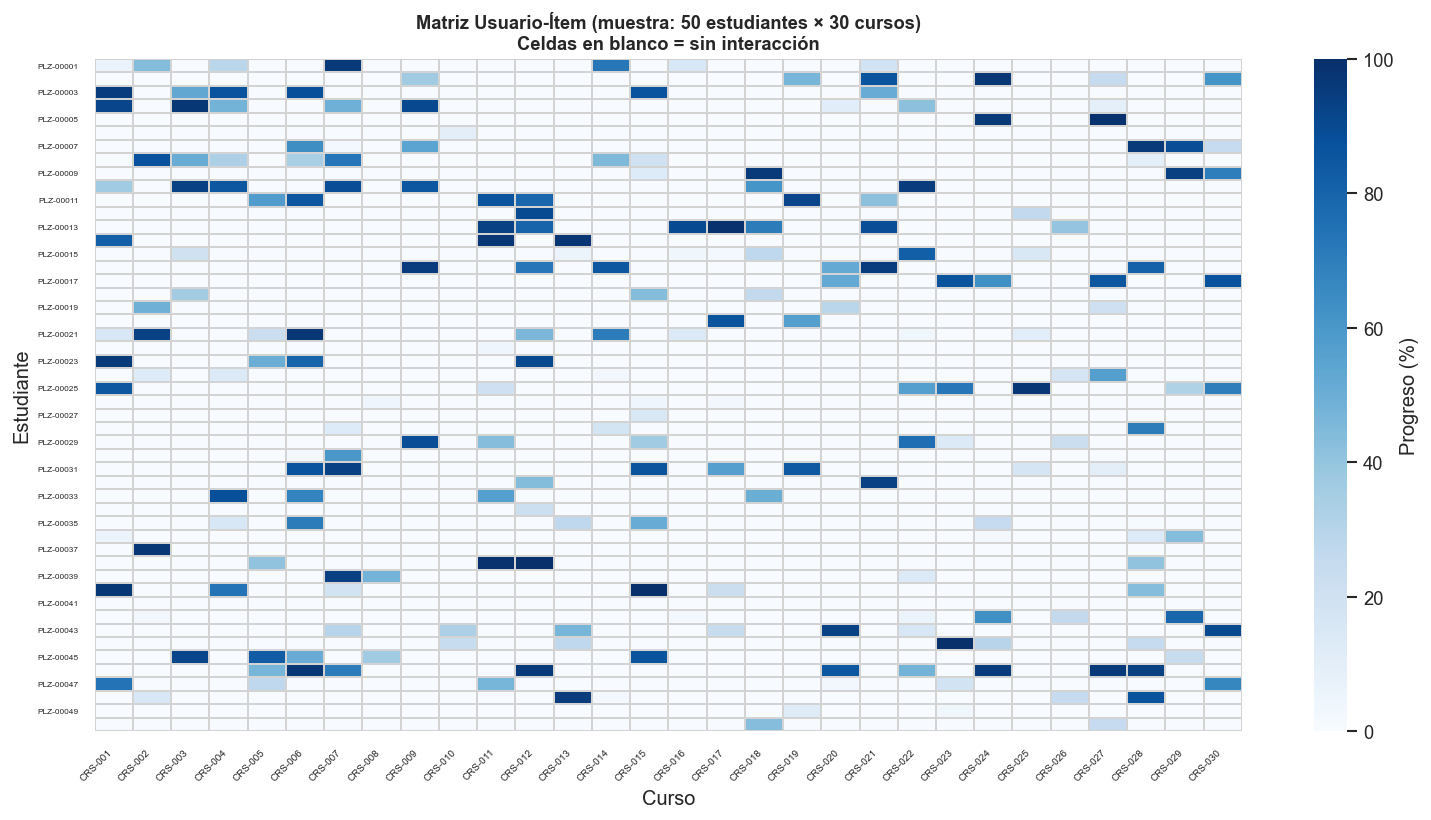

In [12]:
# Visualizar submatriz (primeros 50 estudiantes × primeros 30 cursos)
sample_students = df_int['student_id'].unique()[:50]
sample_courses  = df_courses['course_id'].tolist()[:30]

sub = df_int[
    df_int['student_id'].isin(sample_students) &
    df_int['course_id'].isin(sample_courses)
].pivot_table(index='student_id', columns='course_id', values='progress', fill_value=0)

# Reindex para mostrar matriz completa con ceros
sub = sub.reindex(index=sample_students, columns=sample_courses, fill_value=0)

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(sub, cmap='Blues', ax=ax, cbar_kws={'label': 'Progreso (%)'},
            linewidths=0.2, linecolor='lightgray')
ax.set_title('Matriz Usuario-Ítem (muestra: 50 estudiantes × 30 cursos)\nCeldas en blanco = sin interacción',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Curso')
ax.set_ylabel('Estudiante')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=6)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=5)
plt.tight_layout()
plt.savefig('../reports/recommender_06_sparsidad.png', bbox_inches='tight')
plt.show()

## 6. Patrones por Plan de Suscripción

C:\Users\adria\AppData\Local\Temp\ipykernel_20960\3268210518.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=plan_order, patch_artist=True,
C:\Users\adria\AppData\Local\Temp\ipykernel_20960\3268210518.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=plan_order, patch_artist=True,
C:\Users\adria\AppData\Local\Temp\ipykernel_20960\3268210518.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=plan_order, patch_artist=True,


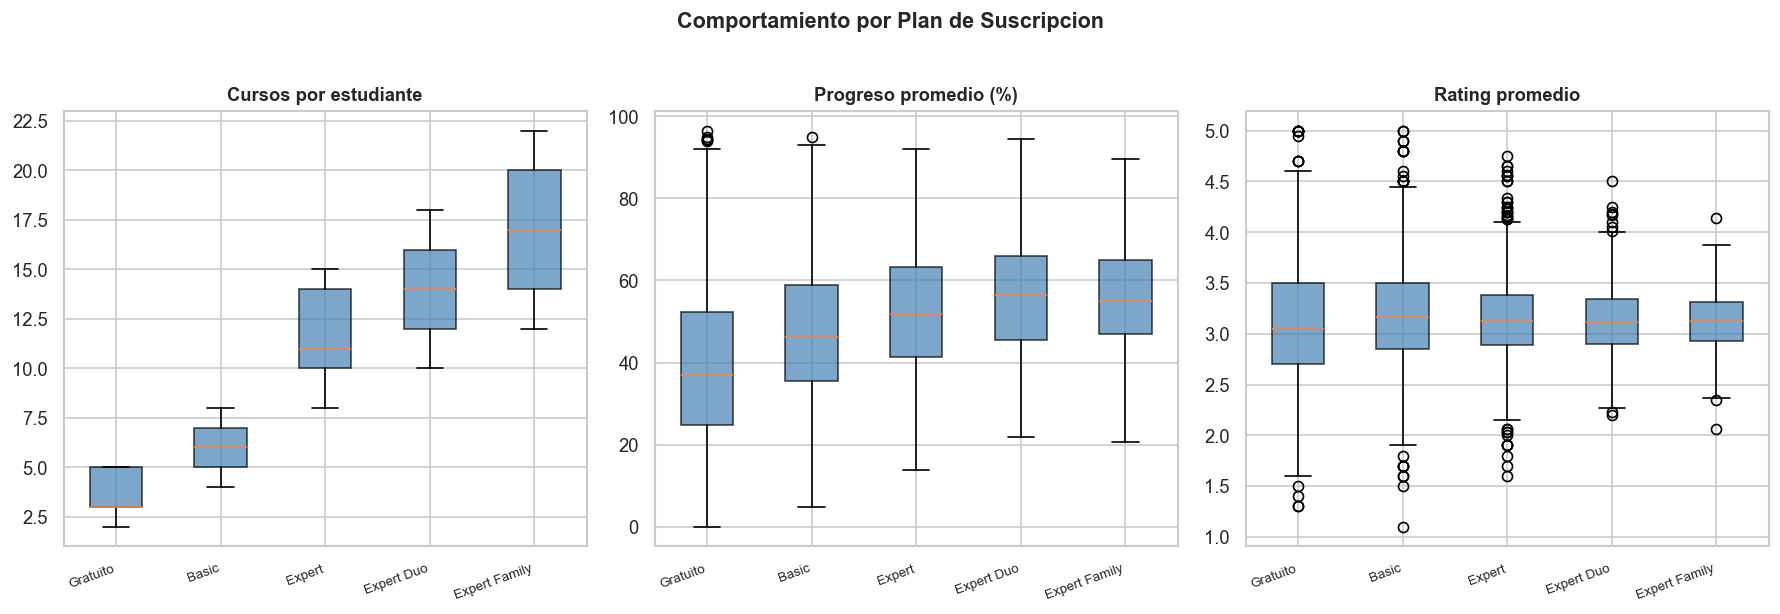

In [13]:
df_churn = pd.read_csv('../data/raw/platzi_churn.csv')[['student_id', 'plan']]
df_with_plan = df_int.merge(df_churn, on='student_id')

# Estadisticas por estudiante (cada fila = un estudiante)
per_student = df_with_plan.groupby(['plan', 'student_id']).agg(
    n_cursos=("course_id", "count"),
    progreso_prom=("progress", "mean"),
    completados=("completed", "sum"),
    rating_prom=("rating", "mean")
).reset_index()

plan_order = ['Gratuito', 'Basic', 'Expert', 'Expert Duo', 'Expert Family']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, title in zip(axes,
    ['n_cursos', 'progreso_prom', 'rating_prom'],
    ['Cursos por estudiante', 'Progreso promedio (%)', 'Rating promedio']):
    data = [per_student[per_student['plan'] == p][col].dropna() for p in plan_order]
    ax.boxplot(data, labels=plan_order, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.7))
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticklabels(plan_order, rotation=20, ha='right', fontsize=8)

plt.suptitle('Comportamiento por Plan de Suscripcion', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/recommender_07_por_plan.png', bbox_inches='tight')
plt.show()

## Conclusiones del EDA

| Hallazgo | Implicación para el modelo |
|----------|---------------------------|
| Sparsidad ~90% | Necesitamos SVD para encontrar patrones latentes |
| Media 8 cursos/estudiante | Suficiente señal por usuario |
| 60%+ interacciones con rating | Podemos usar ratings como feedback explícito |
| Rating promedio 4.1 | Los usuarios satisfechos con la plataforma |
| Plan Expert toma 2× más cursos | El plan predice engagement, útil como feature |

In [14]:
print('=== Resumen final del EDA ===')
print(f'Cursos en el catálogo:         {len(df_courses)}')
print(f'Escuelas representadas:        {df_courses["school"].nunique()}')
print(f'Interacciones totales:         {len(df_int):,}')
print(f'Estudiantes activos:           {n_students:,}')
print(f'Media cursos/estudiante:       {n_filled/n_students:.1f}')
print(f'Sparsidad de la matriz:        {sparsity:.1%}')
print(f'Interacciones con rating:      {df_int["rating"].notna().sum():,}')
print(f'Rating promedio global:        {df_int["rating"].mean():.2f}')
print(f'Tasa de completado global:     {df_int["completed"].mean():.1%}')
print(f'\nGráficos guardados en reports/ (recommender_01 a 07)')

=== Resumen final del EDA ===
Cursos en el catálogo:         83
Escuelas representadas:        15
Interacciones totales:         44,864
Estudiantes activos:           4,891
Media cursos/estudiante:       9.2
Sparsidad de la matriz:        88.9%
Interacciones con rating:      19,879
Rating promedio global:        3.15
Tasa de completado global:     21.3%

Gráficos guardados en reports/ (recommender_01 a 07)
